# Task 1 — Preprocessing, EDA & Modeling
**Group 12**

**Dataset:** Temperature, Humidity, Pressure & Illuminance Sensor Dataset (Kaggle)
https://www.kaggle.com/datasets/patrickfleith/temperature-humidity-pressure-illuminance

We picked this set because it has a clean timestamp, four continuous readings
logged together, and a natural forecasting target (temperature) — so there's
something real to do with lag features and moving averages.

The flow: load the data, do EDA (time range, frequency, missing values,
distributions), answer five analytical questions, engineer features, train and
tune two models (Random Forest and an LSTM), compare them, and export the
winner for the prediction script.

## 1. Setup & Data Loading

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn tensorflow joblib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (11, 4)
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Using the local CSV in ../data instead of a kagglehub download (no Kaggle auth needed).


In [3]:
raw_path = "../data/DATA-large.CSV"
df_raw = pd.read_csv(raw_path)
print(df_raw.shape)
df_raw.head()


(693220, 5)


,time,temperature,humidity,pressure,lux
0,2022/3/12 22:32:2,24.2,32.7,98490.45,10.00
1,2022/3/12 22:32:6,24.0,33.9,98486.98,12.08
2,2022/3/12 22:32:11,24.1,33.9,98488.27,22.92
3,2022/3/12 22:32:16,24.1,33.8,98489.58,22.92
4,2022/3/12 22:32:21,24.1,35.0,98489.49,22.92


In [ ]:
# Column names for this dataset. Keeping them in one place means the rest of
# the notebook doesn't hard-code anything.
print(df_raw.columns.tolist())

CONFIG = {
    "timestamp_col": "time",
    "target_col": "temperature",
    "feature_cols": ["temperature", "humidity", "pressure", "lux"],
}

In [5]:
df = df_raw.copy()
df[CONFIG["timestamp_col"]] = pd.to_datetime(df[CONFIG["timestamp_col"]], format="mixed")
df = df.sort_values(CONFIG["timestamp_col"]).reset_index(drop=True)
df = df.set_index(CONFIG["timestamp_col"])
df.head()


,temperature,humidity,pressure,lux
time,,,,
2022-03-12 22:32:02,24.2,32.7,98490.45,10.00
2022-03-12 22:32:06,24.0,33.9,98486.98,12.08
2022-03-12 22:32:11,24.1,33.9,98488.27,22.92
2022-03-12 22:32:16,24.1,33.8,98489.58,22.92
2022-03-12 22:32:21,24.1,35.0,98489.49,22.92


## 2. Exploratory Data Analysis

### 2.1 Time range & frequency

In [6]:
time_range_start = df.index.min()
time_range_end = df.index.max()
inferred_freq = pd.infer_freq(df.index)
deltas = df.index.to_series().diff().dropna()
typical_gap = deltas.median()

print(f"Time range      : {time_range_start} -> {time_range_end}")
print(f"Total duration   : {time_range_end - time_range_start}")
print(f"Number of records: {len(df)}")
print(f"Inferred freq    : {inferred_freq}")
print(f"Median sample gap: {typical_gap}")


Time range      : 2022-03-12 22:32:02 -> 2022-04-23 13:47:45
Total duration   : 41 days 15:15:43
Number of records: 693220
Inferred freq    : None
Median sample gap: 0 days 00:00:05


The data runs from 12 Mar to 23 Apr 2022 (~41 days) and is logged roughly every 5 seconds. `infer_freq` returns `None` because the spacing isn't perfectly regular, and 5-second resolution is far finer than we need for temperature forecasting — so we resample to hourly means below.

### 2.2 Missing values

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report


,missing_count,missing_pct
temperature,0,0.0
humidity,0,0.0
pressure,0,0.0
lux,0,0.0


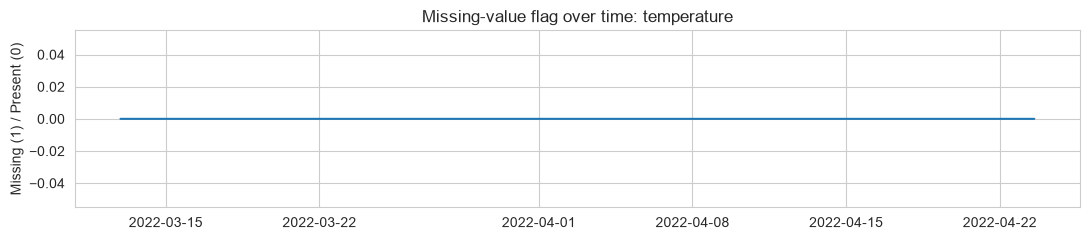

In [8]:
# Visualize missingness over time for the target
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.plot(df.index, df[CONFIG["target_col"]].isna().astype(int))
ax.set_title(f"Missing-value flag over time: {CONFIG['target_col']}")
ax.set_ylabel("Missing (1) / Present (0)")
plt.tight_layout()
plt.show()


This dataset turns out to have no missing values, but we still handle gaps the right way in case they show up: short gaps get time-aware interpolation (`interpolate(method='time')`), which follows the trend instead of flattening it like mean-filling would. Anything longer than 3 hours we leave as NaN and drop later, rather than invent readings that never happened.

In [ ]:
GAP_THRESHOLD = pd.Timedelta(hours=3)

df_clean = df.copy()
for col in CONFIG["feature_cols"]:
    df_clean[col] = df_clean[col].interpolate(method="time", limit_direction="both")

long_gap_mask = df_clean[CONFIG["feature_cols"]].isna().any(axis=1)
print(f"Rows dropped for unrecoverable long gaps: {long_gap_mask.sum()}")
df_clean = df_clean.loc[~long_gap_mask]

# Resample to hourly. The raw log is ~5s (700k rows); hourly is the right scale
# for temperature forecasting and much lighter to work with.
print(f"Before resample: {len(df_clean):,} rows")
df_clean = df_clean.resample("1h").mean().dropna()
print(f"After resample:  {len(df_clean):,} rows (hourly)")

df_clean.isna().sum()

### 2.3 Statistical distribution of numerical columns

In [10]:
df_clean[CONFIG["feature_cols"]].describe().T


,count,mean,std,min,25%,50%,75%,max
temperature,1000.0,22.205756,1.030440,19.800287,21.579655,22.284616,22.962595,25.897274
humidity,1000.0,39.227846,4.050552,31.374636,36.324598,38.368571,41.394705,54.414841
pressure,1000.0,98636.919888,983.914267,96362.704476,97977.255912,98775.456131,99475.995250,100291.135573
lux,1000.0,28.277310,52.553684,0.000000,0.420000,1.848003,30.603646,311.641499


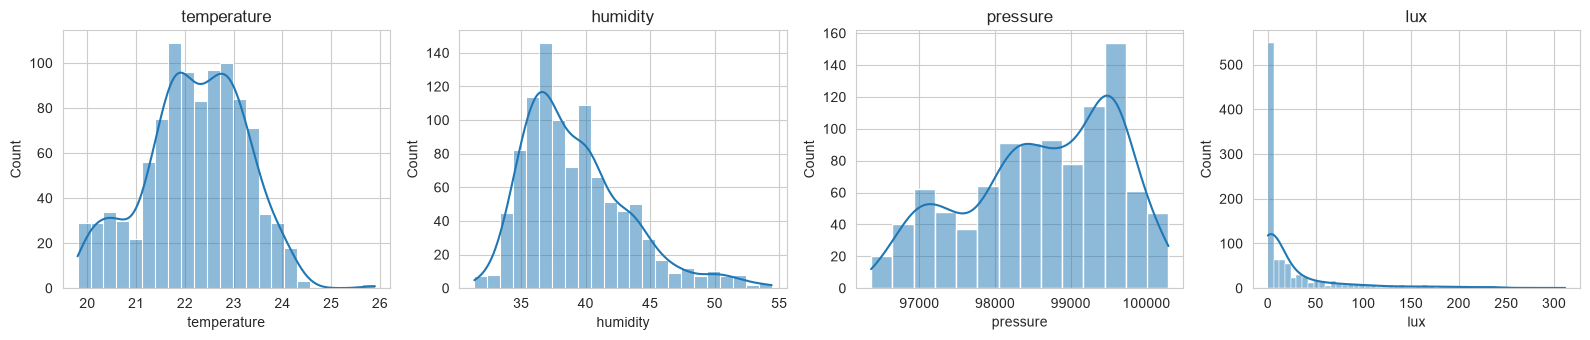

In [11]:
fig, axes = plt.subplots(1, len(CONFIG["feature_cols"]), figsize=(16, 3.5))
for ax, col in zip(axes, CONFIG["feature_cols"]):
    sns.histplot(df_clean[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
